In [27]:
import os
import sys
import logging
import pandas as pd
import tqdm
from helper_dev_utils import get_auto_logger, set_pandas_extension

logger = get_auto_logger(log_level=logging.DEBUG)


In [ ]:
# 의존성 확인 함수
def check_dependencies():
    """transformers, torch, sentencepiece 설치 여부 확인"""
    dependencies = {
        'transformers': None,
        'torch': None,
        'sentencepiece': None
    }
    
    for package in dependencies.keys():
        module = __import__(package)
        version = getattr(module, '__version__', 'unknown')
        dependencies[package] = version
        logger.info(f"{package}: {version}")
    
    return dependencies

# 의존성 확인 실행
deps = check_dependencies()
all_installed = all(v is not None for v in deps.values())

if not all_installed:
    logger.error("⚠️ 필요한 패키지가 설치되지 않았습니다.")
    logger.info("설치 명령: pip install transformers torch sentencepiece")
else:
    logger.info("모든 필요한 패키지가 설치되어 있습니다.")


c:\Users\sw1\anaconda3\envs\mis18\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


2025-12-19 09:08:51 I [ipykernel_launcher:14] - ✅ transformers: 4.57.3
2025-12-19 09:08:51 I [ipykernel_launcher:14] - ✅ torch: 2.9.1+cpu
2025-12-19 09:08:51 I [ipykernel_launcher:14] - ✅ sentencepiece: 0.2.1
2025-12-19 09:08:51 I [ipykernel_launcher:26] - ✅ 모든 필요한 패키지가 설치되어 있습니다.
2025-12-19 09:08:51 I [ipykernel_launcher:14] - ✅ torch: 2.9.1+cpu
2025-12-19 09:08:51 I [ipykernel_launcher:14] - ✅ sentencepiece: 0.2.1
2025-12-19 09:08:51 I [ipykernel_launcher:26] - ✅ 모든 필요한 패키지가 설치되어 있습니다.


In [ ]:
# 감성 분류 파이프라인 로드 (의존성 설치 후 실행)
from transformers import pipeline

logger.info("🔄 koelectra-small-v3-nsmc 모델 로드 중...")
sentiment_pipeline = pipeline(
    "text-classification",
    model="daekeun-ml/koelectra-small-v3-nsmc"
)
logger.info("모델 로드 완료")


2025-12-19 09:17:55 I [ipykernel_launcher:4] - 🔄 koelectra-small-v3-nsmc 모델 로드 중...


Xet Storage is enabled for this repo, but the 'hf_xet' package is not installed. Falling back to regular HTTP download. For better performance, install the package with: `pip install huggingface_hub[hf_xet]` or `pip install hf_xet`
Device set to use cpu
Device set to use cpu


2025-12-19 09:18:04 I [ipykernel_launcher:9] - ✅ 모델 로드 완료


In [ ]:
# 레이블 매핑 검증 함수
def test_label_mapping(pipeline_model, test_texts: list[str]) -> pd.DataFrame:
    """
    모델 출력 레이블을 확인하고 is_positive 필드(0: 부정, 1: 긍정)로 매핑 테스트
    
    Args:
        pipeline_model: HuggingFace 파이프라인 모델
        test_texts: 테스트할 텍스트 리스트
    
    Returns:
        pd.DataFrame: 텍스트, 원본 레이블, 매핑 결과를 포함한 데이터프레임
    """
    results = []
    
    for text in test_texts:
        # 파이프라인 예측
        prediction = pipeline_model(text)[0]
        raw_label = prediction['label']
        confidence = prediction['score']
        
        # is_positive 매핑 (0: 부정, 1: 긍정)
        # koelectra-small-v3-nsmc는 'positive'/'negative' 또는 'LABEL_0'/'LABEL_1' 반환 가능
        if raw_label.lower() in ['positive', 'label_1', '1']:
            is_positive = 1
        elif raw_label.lower() in ['negative', 'label_0', '0']:
            is_positive = 0
        else:
            is_positive = None  # 알 수 없는 레이블
            
        results.append({
            'text': text,
            'raw_label': raw_label,
            'confidence': confidence,
            'is_positive': is_positive,
            'mapped_label': '긍정' if is_positive == 1 else '부정' if is_positive == 0 else '알 수 없음'
        })
        
        logger.debug(f"텍스트: {text[:30]}... | 원본: {raw_label} | 매핑: {is_positive}")
    
    return pd.DataFrame(results)

# 테스트 샘플 (긍정/부정 명확한 리뷰)
test_reviews = [
    "이 영화 정말 최고예요! 강력 추천합니다.",
    "시간 낭비했네요. 정말 지루한 영화.",
    "배우들의 연기가 훌륭했어요. 감동적이었습니다.",
    "스토리가 엉망이고 연출도 형편없었어요.",
    "올해 본 영화 중 최고! 꼭 보세요.",
    "돈이 아깝습니다. 절대 비추천."
]

# 레이블 매핑 테스트 실행
logger.info("레이블 매핑 테스트 시작...")
df_test = test_label_mapping(sentiment_pipeline, test_reviews)
logger.info("레이블 매핑 테스트 완료")

df_test


2025-12-19 09:19:31 I [ipykernel_launcher:53] - 🧪 레이블 매핑 테스트 시작...
2025-12-19 09:19:31 D [ipykernel_launcher:38] - 텍스트: 이 영화 정말 최고예요! 강력 추천합니다.... | 원본: 1 | 매핑: 1
2025-12-19 09:19:31 D [ipykernel_launcher:38] - 텍스트: 시간 낭비했네요. 정말 지루한 영화.... | 원본: 0 | 매핑: 0
2025-12-19 09:19:31 D [ipykernel_launcher:38] - 텍스트: 이 영화 정말 최고예요! 강력 추천합니다.... | 원본: 1 | 매핑: 1
2025-12-19 09:19:31 D [ipykernel_launcher:38] - 텍스트: 시간 낭비했네요. 정말 지루한 영화.... | 원본: 0 | 매핑: 0
2025-12-19 09:19:31 D [ipykernel_launcher:38] - 텍스트: 배우들의 연기가 훌륭했어요. 감동적이었습니다.... | 원본: 1 | 매핑: 1
2025-12-19 09:19:31 D [ipykernel_launcher:38] - 텍스트: 배우들의 연기가 훌륭했어요. 감동적이었습니다.... | 원본: 1 | 매핑: 1
2025-12-19 09:19:31 D [ipykernel_launcher:38] - 텍스트: 스토리가 엉망이고 연출도 형편없었어요.... | 원본: 0 | 매핑: 0
2025-12-19 09:19:31 D [ipykernel_launcher:38] - 텍스트: 스토리가 엉망이고 연출도 형편없었어요.... | 원본: 0 | 매핑: 0
2025-12-19 09:19:31 D [ipykernel_launcher:38] - 텍스트: 올해 본 영화 중 최고! 꼭 보세요.... | 원본: 1 | 매핑: 1
2025-12-19 09:19:31 D [ipykernel_launcher:38] - 텍스트: 올해 본 영화 중 최고! 꼭 보세요.... |

,text,raw_label,confidence,is_positive,mapped_label
0,이 영화 정말 최고예요! 강력 추천합니다.,1,0.997165,1,긍정
1,시간 낭비했네요. 정말 지루한 영화.,0,0.999243,0,부정
2,배우들의 연기가 훌륭했어요. 감동적이었습니다.,1,0.999104,1,긍정
3,스토리가 엉망이고 연출도 형편없었어요.,0,0.999550,0,부정
4,올해 본 영화 중 최고! 꼭 보세요.,1,0.995216,1,긍정
5,돈이 아깝습니다. 절대 비추천.,0,0.999499,0,부정


In [ ]:
# 전처리가 통합된 개선된 SentimentPredictor 클래스
class SentimentPredictor:
    """
    한국어 영화 리뷰 감성 분석 클래스 (전처리 통합)
    daekeun-ml/koelectra-small-v3-nsmc 모델 사용
    """
    
    def __init__(self):
        """감성 분석 파이프라인 초기화"""
        from transformers import pipeline
        self.model = pipeline(
            "text-classification",
            model="daekeun-ml/koelectra-small-v3-nsmc"
        )
        self.max_length = 512  # koelectra 모델 최대 토큰 수
        logger.info("SentimentPredictor 초기화 완료")
        
    def _predict(self, text: str) -> int:
        """
        텍스트의 감성을 예측합니다.
        
        Args:
            text: 분석할 텍스트 (원본 그대로 가능)
        
        Returns:
            int: 0 (부정) 또는 1 (긍정)
        """
        if not text or not isinstance(text, str):
            return 0
        
        # pipeline이 자동 처리
        result = self.model(text)[0]
        
        # 레이블 매핑
        is_positive = 1 if result['label'].lower() in ['positive', 'label_1', '1'] else 0
        return is_positive
    

    def _predict_batch(self, texts: list[str]) -> list[int]:
        """
        여러 텍스트의 감성을 일괄 예측합니다.
        
        Args:
            texts: 분석할 텍스트 리스트
        
        Returns:
            list[int]: 각 텍스트의 예측 결과 (0: 부정, 1: 긍정)
        """
        
        if not texts:
            logger.warning("유효한 텍스트가 없습니다.")
            return [0] * len(texts)
        
        # 배치 감성 분석
        results = self.model(texts)
        
        # 레이블 매핑
        predictions = []
        for result in results:
            raw_label = result['label']
            is_positive = 1 if raw_label.lower() in ['positive', 'label_1', '1'] else 0
            predictions.append(is_positive)
        
        # logger.debug(f"배치 예측 완료: {len(predictions)}개 텍스트")
        return predictions
    
    
    def predict(self, text: str) -> int:
        """
        512 보다 긴 텍스트의 경우 문장 단위 혹은 길이 단위로 나워 감정 분류를 한다음에
        가장 많이 나온 결과를 반환합니다.
        동일 할경우 부정을 반환 합니다.
        20%를 겹치게 한다.
        
        Args:
            text: 분석할 텍스트
        
        Returns:
            텍스트의 예측 결과 (0: 부정, 1: 긍정)
        """
        
        if len(text) > (self.max_length * 1.2):
            texts = []
            for i in range(0, len(text), int(self.max_length * 0.8)):
                chunk = text[i:i + self.max_length]
                texts.append(chunk)
            predictions = self.predict_batch(texts)
            pos_count = predictions.count(1)
            neg_count = predictions.count(0)
            
            # 가장 많이 나온 결과 반환
            # 동일 할경우 부정을 반환
            if pos_count > neg_count:
                return 1
            else:
                return 0
        else:
            return self._predict(text)
    
    def predict_batch(self, texts: list[str]) -> list[int]:
        return self._predict_batch(texts)

    def predict_text(self, text: str) -> int:
        """
        512 보다 긴 텍스트의 경우 문장 단위 혹은 길이 단위로 나워 감정 분류를 한다음에
        가장 많이 나온 결과를 반환합니다.
        동일 할경우 부정을 반환 합니다.
        20%를 겹치게 한다.
        
        Args:
            text: 분석할 텍스트
        
        Returns:
            텍스트의 예측 결과 (0: 부정, 1: 긍정)
        """
        
        if len(text) > (self.max_length * 1.2):
            texts = []
            for i in range(0, len(text), int(self.max_length * 0.8)):
                chunk = text[i:i + self.max_length]
                texts.append(chunk)
            predictions = self.predict_batch(texts)
            pos_count = predictions.count(1)
            neg_count = predictions.count(0)
            
            # 가장 많이 나온 결과 반환
            # 동일 할경우 부정을 반환
            if pos_count > neg_count:
                return 1
            else:
                return 0
        else:
            return self._predict(text)


    def predict_texts(self, texts: list[str]) -> list[int]:
        """
        여러 텍스트의 감성을 일괄 예측합니다.
        
        Args:
            texts: 분석할 텍스트 리스트
        
        Returns:
            list[int]: 각 텍스트의 예측 결과 (0: 부정, 1: 긍정)
        """
        
        if not texts:
            logger.warning("유효한 텍스트가 없습니다.")
            return [0] * len(texts)
        
        results = []
        for text in texts:
            result = self.predict_text(text)
            results.append(result)
        return results


In [32]:

# 개선된 클래스 테스트
logger.info("SentimentPredictor 테스트 시작...")
predictor = SentimentPredictor()

# 1. 일반 케이스
test_cases = [
    "정말 재미있는 영화였어요!",
    "최악의 영화입니다.",
    "배우 연기가 좋았습니다.",
]

logger.info("--- 일반 케이스 테스트 ---")
for text in test_cases:
    predicted = predictor.predict_text(text)
    label = "긍정" if predicted == 1 else "부정"
    logger.info(f"'{text}' -> {label} ({predicted})")

# 2. 긴 텍스트 케이스
long_review = """
이 영화는 정말 훌륭했습니다. 스토리는 탄탄하고 배우들의 연기는 감동적이었습니다. 
특히 주연 배우의 섬세한 감정 표현이 인상 깊었고, 촬영 기법도 매우 예술적이었습니다.
영화를 보는 내내 몰입할 수 있었고, 엔딩 크레딧이 올라갈 때까지 자리에서 일어날 수 없었습니다.
""" * 10  # 긴 텍스트 시뮬레이션

logger.info(f"--- 긴 텍스트 케이스 테스트 (원본: {len(long_review)}자) ---")
predicted = predictor.predict_text(long_review)
logger.info(f"예측 결과: {'긍정' if predicted == 1 else '부정'} ({predicted})")

# 3. 배치 예측 테스트
batch_texts = [
    "정말 최고의 영화!",
    "돈 아까웠어요",
    "볼만한 영화였습니다",
    "다시는 안 봅니다",
    "강추합니다!"
]

logger.info("--- 배치 예측 테스트 ---")
batch_predictions = predictor.predict_batch(batch_texts)
for text, pred in zip(batch_texts, batch_predictions):
    label = "긍정" if pred == 1 else "부정"
    logger.info(f"'{text}' -> {label} ({pred})")

logger.info("SentimentPredictor 테스트 완료")

2025-12-19 10:34:15 I [ipykernel_launcher:2] - SentimentPredictor 테스트 시작...


Device set to use cpu


2025-12-19 10:34:16 I [ipykernel_launcher:16] - SentimentPredictor 초기화 완료
2025-12-19 10:34:16 I [ipykernel_launcher:12] - --- 일반 케이스 테스트 ---
2025-12-19 10:34:16 I [ipykernel_launcher:16] - '정말 재미있는 영화였어요!' -> 긍정 (1)
2025-12-19 10:34:16 I [ipykernel_launcher:16] - '최악의 영화입니다.' -> 부정 (0)
2025-12-19 10:34:17 I [ipykernel_launcher:16] - '배우 연기가 좋았습니다.' -> 긍정 (1)
2025-12-19 10:34:17 I [ipykernel_launcher:25] - --- 긴 텍스트 케이스 테스트 (원본: 1520자) ---
2025-12-19 10:34:17 I [ipykernel_launcher:27] - 예측 결과: 긍정 (1)
2025-12-19 10:34:17 I [ipykernel_launcher:38] - --- 배치 예측 테스트 ---
2025-12-19 10:34:17 I [ipykernel_launcher:42] - '정말 최고의 영화!' -> 긍정 (1)
2025-12-19 10:34:17 I [ipykernel_launcher:42] - '돈 아까웠어요' -> 부정 (0)
2025-12-19 10:34:17 I [ipykernel_launcher:42] - '볼만한 영화였습니다' -> 긍정 (1)
2025-12-19 10:34:17 I [ipykernel_launcher:42] - '다시는 안 봅니다' -> 부정 (0)
2025-12-19 10:34:17 I [ipykernel_launcher:42] - '강추합니다!' -> 긍정 (1)
2025-12-19 10:34:17 I [ipykernel_launcher:44] - SentimentPredictor 테스트 완료


In [33]:

with open(r"D:\temp\nsmc\ratings_train.txt","r",encoding="utf-8") as f:
    lines = f.readlines()
    logger.debug(f"파일에서 읽은 라인 수: {len(lines)}")
    for i, line in enumerate(lines[:5]):  # 처음 5줄만 출력
        logger.debug(f"라인 {i+1}: {line.strip()}")
        txts = line.strip().split("\t")
        id = txts[0]
        level = txts[-1]
        review = " ".join(txts[1:-1])
        logger.debug(f"ID: [{id}], 리뷰: [{review}], 레벨: [{level}]")


2025-12-19 10:34:20 D [ipykernel_launcher:3] - 파일에서 읽은 라인 수: 150001
2025-12-19 10:34:20 D [ipykernel_launcher:5] - 라인 1: id	document	label
2025-12-19 10:34:20 D [ipykernel_launcher:10] - ID: [id], 리뷰: [document], 레벨: [label]
2025-12-19 10:34:20 D [ipykernel_launcher:5] - 라인 2: 9976970	아 더빙.. 진짜 짜증나네요 목소리	0
2025-12-19 10:34:20 D [ipykernel_launcher:10] - ID: [9976970], 리뷰: [아 더빙.. 진짜 짜증나네요 목소리], 레벨: [0]
2025-12-19 10:34:20 D [ipykernel_launcher:5] - 라인 3: 3819312	흠...포스터보고 초딩영화줄....오버연기조차 가볍지 않구나	1
2025-12-19 10:34:20 D [ipykernel_launcher:10] - ID: [3819312], 리뷰: [흠...포스터보고 초딩영화줄....오버연기조차 가볍지 않구나], 레벨: [1]
2025-12-19 10:34:20 D [ipykernel_launcher:5] - 라인 4: 10265843	너무재밓었다그래서보는것을추천한다	0
2025-12-19 10:34:20 D [ipykernel_launcher:10] - ID: [10265843], 리뷰: [너무재밓었다그래서보는것을추천한다], 레벨: [0]
2025-12-19 10:34:20 D [ipykernel_launcher:5] - 라인 5: 9045019	교도소 이야기구먼 ..솔직히 재미는 없다..평점 조정	0
2025-12-19 10:34:20 D [ipykernel_launcher:10] - ID: [9045019], 리뷰: [교도소 이야기구먼 ..솔직히 재미는 없다..평점 조정], 레벨: [0]


In [34]:
df = pd.read_csv(
    r"D:\temp\nsmc\ratings_train.txt",
    sep="\t",
    header=0,  # 첫 줄을 헤더로 사용
    dtype={"label": str}
)

logger.debug(f"개수:{len(df)}")
logger.debug(f"레이블 분포:{df['label'].value_counts()}")
print("-" * 80)
print(df.describe())
print("-" * 80)
df.head()

2025-12-19 10:34:23 D [ipykernel_launcher:8] - 개수:150000
2025-12-19 10:34:23 D [ipykernel_launcher:9] - 레이블 분포:label
0    75173
1    74827
Name: count, dtype: int64
--------------------------------------------------------------------------------
                 id
count  1.500000e+05
mean   6.743533e+06
std    2.919051e+06
min    3.300000e+01
25%    4.766881e+06
50%    7.526840e+06
75%    9.249435e+06
max    1.027815e+07
--------------------------------------------------------------------------------
         id                                                                                                        document label
 0  9976970                                                                                아 더빙.. 진짜 짜증나네요 목소리     0
 1  3819312                                                        흠...포스터보고 초딩영화줄....오버연기조차 가볍지 않구나     1
 2 10265843                                                                              너무재밓었다그래서보는것을추천한다     0
 3  9045019               

In [36]:

def predict_df(df: pd.DataFrame, predictor: SentimentPredictor, batch_size: int = 32) -> pd.DataFrame:
    """
    DataFrame의 'document' 컬럼을 batch_size 단위로 예측하여 결과 DataFrame 반환

    Args:
        df: 입력 DataFrame (필수 컬럼: 'id', 'document', 'label')
        predictor: SentimentPredictor 인스턴스
        batch_size: 배치 크기 (기본 32)

    Returns:
        pd.DataFrame: ['id','document','label','predicted','predicted_label']
    """
    # 실행 전: conda activate mis18
    required = {'id', 'document', 'label'}
    if not required.issubset(df.columns):
        raise ValueError(f"DataFrame에 필요한 컬럼 누락: {required - set(df.columns)}")

    rows: list[list] = []
    texts = df['document'].astype(str).tolist()
    ids = df['id'].tolist()
    labels = df['label'].tolist()
    n = len(texts)

    # predict_text / predict_texts 기반 테스트: predict_text의 긴 텍스트 분할 로직을 검증하기 위해 predict_texts 사용
    pbar = tqdm.tqdm(range(0, n, batch_size), desc="배치(predict_texts) 진행 중", unit="배치")
    for start in pbar:
        end = min(start + batch_size, n)
        batch_texts = texts[start:end]
        preds = predictor.predict_texts(batch_texts)
        for i, (text, pred) in enumerate(zip(batch_texts, preds)):
            idx = ids[start + i]
            true_label = labels[start + i]
            predicted_label = '1' if int(pred) == 1 else '0'
            rows.append([idx, text, true_label, int(pred), predicted_label])
        pbar.set_postfix(processed=end)

    return pd.DataFrame(rows, columns=['id', 'document', 'label', 'predicted', 'predicted_label'])

# 사용 예: 전체 데이터에 대해 배치 예측
# 꼭 conda activate mis18 후 실행하세요.
df_predict = predict_df(df[:1000], predictor)
df_predict.head()

배치(predict_texts) 진행 중: 100%|██████████| 32/32 [00:31<00:00,  1.02배치/s, processed=1000]

         id                                                                                                        document label predicted predicted_label
 0  9976970                                                                                아 더빙.. 진짜 짜증나네요 목소리     0         0               0
 1  3819312                                                        흠...포스터보고 초딩영화줄....오버연기조차 가볍지 않구나     1         1               1
 2 10265843                                                                              너무재밓었다그래서보는것을추천한다     0         1               1
 3  9045019                                                               교도소 이야기구먼 ..솔직히 재미는 없다..평점 조정     0         0               0
 4  6483659 사이몬페그의 익살스런 연기가 돋보였던 영화!스파이더맨에서 늙어보이기만 했던 커스틴 던스트가 너무나도 이뻐보였다     1         1               1


정확도: 0.9780


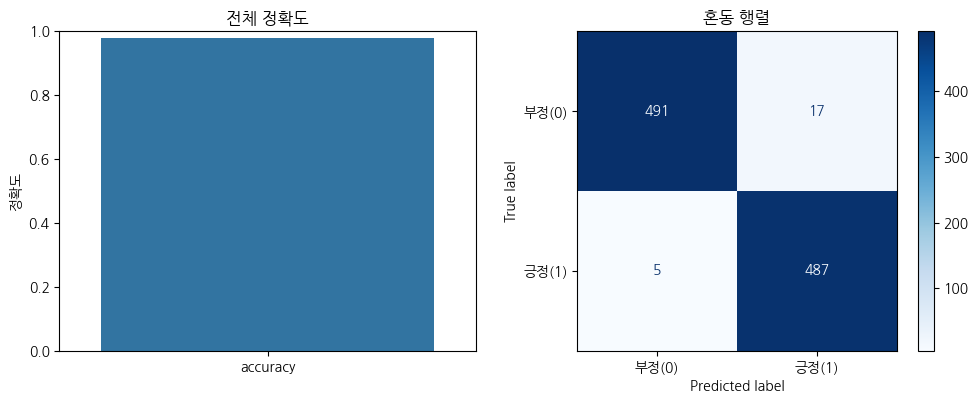

In [41]:
# ...existing code...
# 검증율(정확도) 및 혼동행렬 시각화
# 실행 전: conda activate mis18
from helper_plot_hangul import matplotlib_font_reset
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay

def plot_validation(df_predict):
    """
    df_predict의 'label'과 'predicted'로 정확도와 혼동행렬을 그립니다.
    """
    df = df_predict.copy()
    df['label'] = df['label'].astype(int)
    df['predicted'] = df['predicted'].astype(int)

    acc = accuracy_score(df['label'], df['predicted'])
    cm = confusion_matrix(df['label'], df['predicted'])

    print(f"정확도: {acc:.4f}")

    fig, axes = plt.subplots(1, 2, figsize=(10, 4))
    sns.barplot(x=['accuracy'], y=[acc], ax=axes[0])
    axes[0].set_ylim(0, 1)
    axes[0].set_ylabel('정확도')
    axes[0].set_title('전체 정확도')

    disp = ConfusionMatrixDisplay(cm, display_labels=['부정(0)', '긍정(1)'])
    disp.plot(ax=axes[1], cmap='Blues', values_format='d')
    axes[1].set_title('혼동 행렬')

    plt.tight_layout()
    plt.show()

plot_validation(df_predict)


In [ ]:
# df_predict 상태 확인 및 테이블 출력
logger.info("=== df_predict 상태 확인 ===")

# 1. 기본 정보
print("\n[1] 기본 정보")
print(f"Shape: {df_predict.shape}")
print(f"Columns: {df_predict.columns.tolist()}")
print(f"\nData Types:\n{df_predict.dtypes}")

# 2. 샘플 데이터
print("\n[2] 처음 5개 샘플")
print(df_predict.head())

print("\n[3] 마지막 5개 샘플")
print(df_predict.tail())

# 3. 레이블 분포
print("\n[4] 실제 레이블 분포")
print(df_predict['label'].value_counts())

print("\n[5] 예측 레이블 분포")
print(df_predict['predicted'].value_counts())

# 4. 누락 데이터 확인
print("\n[6] 누락 데이터 (NaN)")
print(df_predict.isnull().sum())

# 5. 예측 불일치 케이스
print("\n[7] 예측 불일치 샘플 (처음 10개)")
mismatch = df_predict[df_predict['label'].astype(int) != df_predict['predicted']]
print(f"불일치 개수: {len(mismatch)}/{len(df_predict)}")
if len(mismatch) > 0:
    print(mismatch[['id', 'document', 'label', 'predicted']].head(10))
else:
    print("불일치 없음")

# 6. 데이터 요약
print("\n[8] 통계 요약")
print(df_predict.describe(include='all'))

logger.info("df_predict 상태 확인 완료")

2025-12-19 10:41:30 I [ipykernel_launcher:4] - === df_predict 상태 확인 ===

[1] 기본 정보
Shape: (1000, 5)
Columns: ['id', 'document', 'label', 'predicted', 'predicted_label']

Data Types:
id                  int64
document           object
label              object
predicted           int64
predicted_label    object
dtype: object

[2] 처음 5개 샘플
         id                                                                                                        document label predicted predicted_label
 0  9976970                                                                                아 더빙.. 진짜 짜증나네요 목소리     0         0               0
 1  3819312                                                        흠...포스터보고 초딩영화줄....오버연기조차 가볍지 않구나     1         1               1
 2 10265843                                                                              너무재밓었다그래서보는것을추천한다     0         1               1
 3  9045019                                                               교도소 이야기구먼 ..솔직히

In [44]:
def analyze_label_quality(df_predict: pd.DataFrame, sample_size: int = 50):
    """
    예측 불일치 샘플을 무작위 추출하여 레이블 품질 분석
    
    Args:
        df_predict: 예측 결과 DataFrame
        sample_size: 분석할 샘플 개수
    """
    df = df_predict.copy()
    df['label'] = df['label'].astype(int)
    df['predicted'] = df['predicted'].astype(int)
    
    # 불일치 케이스 추출
    mismatch_df = df[df['label'] != df['predicted']]
    actual_sample_size = min(sample_size, len(mismatch_df))
    mismatch = mismatch_df.sample(actual_sample_size) if len(mismatch_df) > 0 else mismatch_df
    
    # 카테고리별 분류
    false_negative = mismatch[mismatch['predicted'] == 0]  # 모델: 부정, 실제: 긍정
    false_positive = mismatch[mismatch['predicted'] == 1]  # 모델: 긍정, 실제: 부정
    
    print(f"총 불일치: {len(mismatch)}")
    print(f"False Negative (모델 부정 → 실제 긍정): {len(false_negative)}")
    print(f"False Positive (모델 긍정 → 실제 부정): {len(false_positive)}")
    print("\n=== False Positive 샘플 (모델이 긍정으로 예측했으나 레이블은 부정) ===")
    print(false_positive[['document', 'label', 'predicted']].head(20))
    
    return mismatch

# 실행
mismatch_analysis = analyze_label_quality(df_predict, sample_size=100)

총 불일치: 22
False Negative (모델 부정 → 실제 긍정): 5
False Positive (모델 긍정 → 실제 부정): 17

=== False Positive 샘플 (모델이 긍정으로 예측했으나 레이블은 부정) ===
                                             document label predicted
 106                                         킬링타임     0         1
   2               너무재밓었다그래서보는것을추천한다     0         1
 359  잔인하기도 하고 무서웠어요ㅠ탑은 멋있더라구요~~     0         1
 972                                             ㅇㅇ     0         1
 308                                          굿 좋아     0         1
 151                                               아     0         1
 143                                          볼만해;     0         1
 965                       쇼핑백 잊혀지지 않는다....     0         1
  56                                             최고     0         1
 485                          ㄵ 5점대asfgsdlgkbjsjvb     0         1
  48                  난 우리영화를 사랑합니다....^^;     0         1
 498           스킨헤드성님들이 이 영화를 싫어합니다.     0         1
 834 정말 사랑에 대해 다시생각한거같습니다 감동이에요     0         1
 617 